# Exercício 1 — Algoritmos Genéticos: conceitos, exploração de exemplos e melhoria com IA

Este notebook aborda os conceitos de evolução biológica, panoramas de adaptabilidade
(fitness landscapes) e algoritmos genéticos, seguindo as instruções da ementa da Aula 07.


## 1. Contexto

Nesta aula tratamos da contribuição da biologia para os estudos dos sistemas dinâmicos
de muitos agentes. Iniciamos com o desdobramento histórico dos modelos fenomenológicos
e matemáticos dos mecanismos genéticos.

- **Charles Darwin (1859)**: Teoria da evolução por seleção natural
- **Gregor Mendel (1865)**: Leis da hereditariedade
- **Síntese Moderna (1920–1940)**: Unificação da genética mendeliana com a seleção natural darwiniana
- **Sewall Wright (década de 1930)**: Conceito de **panorama de adaptação (fitness landscape)**,
  modelando a evolução genética de uma espécie em um dado ambiente
- **John Holland (década de 1960–1970)**: **Algoritmos genéticos** como ferramentas de
  otimização computacional baseadas nos princípios da evolução

Os algoritmos genéticos são apresentados em vídeos criados por **Victor Pellegrini Mammana**,
disponíveis no YouTube. Um exemplo clássico é o robô catador de latas de **Melanie Mitchell**,
implementado em NetLogo.


## 2. Célula auxiliar — imports e path discovery

Execute a célula abaixo para configurar os imports e os diretórios de saída.


In [1]:
from dotenv import load_dotenv
load_dotenv()

import numpy as np
import matplotlib.pyplot as plt
import random
import os
import shutil
import subprocess
import glob

_repo = os.getcwd()
for _ in range(5):
    if os.path.exists(os.path.join(_repo, "setup.sh")):
        break
    _repo = os.path.dirname(_repo)
PASTA_MOODLE = os.path.join(_repo, "work", "tarefas_moodle")
os.makedirs(PASTA_MOODLE, exist_ok=True)
PASTA_AULA = os.path.join(PASTA_MOODLE, "tarefa_aula07")
os.makedirs(PASTA_AULA, exist_ok=True)
os.environ["PASTA_AULA_SAVE"] = PASTA_AULA
print("Diretorio de saida:", PASTA_AULA)


Diretorio de saida: /l/disk0/viniciusd/Projetos/simserv_jupyter_env/work/tarefas_moodle/tarefa_aula07


## 3. Os 6 programas Python de exemplo

Os arquivos abaixo foram criados com o ChatGPT e estão disponíveis em `tarefas/aula07/`.
Eles exemplificam o uso de algoritmos genéticos para busca de máximos de funções.

| Arquivo | Função de fitness | Biblioteca | Visualização |
|---|---|---|---|
| `demo_alg_gen_GPT.py` | f(x) = x² | Custom (torneio) | 2D interativo (botão) |
| `demo_alg_gen_GPT_100-x2_func.py` | f(x) = 100 − x² | Custom (torneio) | 2D interativo (botão) |
| `demo_alg_gen_GPT_2MAX_Gauss_corrigido.py` | Duas Gaussianas (picos em 2 e 5) | Custom (roleta) | 2D interativo (botão) |
| `PanoramaExemplo.py` | sen(x)·cos(y) + 1.5·exp(−(x²+y²)/10) | Nenhum (só plot) | Superfície 3D estática |
| `Fitness.py` | sen(x)·cos(y) + 1.5·exp(−(x²+y²)/10) | DEAP | Contour 2D (a cada geração) |
| `Fitness_3D.py` | sen(x)·cos(y) + 1.5·exp(−(x²+y²)/10) | DEAP | Superfície 3D (geração final) |

**Instrução da ementa:** abra o Terminal e execute os programas:

```bash
cd tarefas/aula07
python3 demo_alg_gen_GPT.py
python3 demo_alg_gen_GPT_2MAX_Gauss_corrigido.py
python3 demo_alg_gen_GPT_100-x2_func.py
python3 PanoramaExemplo.py
python3 Fitness.py
python3 Fitness_3D.py
```

Os programas interativos abrirão janelas com botão "Próxima Geração".
Observe como o algoritmo genético converge para o máximo ao longo das gerações.


## 4. IA gera código de algoritmo genético

Vamos pedir para a IA gerar um algoritmo genético simples para maximizar
a função f(x) = 100 − x² no intervalo [−10, 10].

Execute a célula abaixo para que a IA gere o código.


In [2]:
import os, json
from urllib.request import Request, urlopen

MODELO = os.getenv("OLLAMA_MODEL", "ministral-3:3b")
BASE_URL = os.getenv("OLLAMA_BASE_URL", "https://api.ollama.com").rstrip("/")
API_KEY = os.getenv("OLLAMA_API_KEY")

prompt_codigo = """Voce e um assistente de um curso de sistemas de muitos agentes.
Gere APENAS codigo Python (sem explicacoes) de um algoritmo genetico completo
para maximizar f(x) = 100 - x**2 no intervalo [-10, 10].
Use: populacao de 10 individuos, selecao por torneio (k=2), crossover blend,
mutacao gaussiana (sigma=1.0, taxa=0.2), 20 geracoes.
Ao final, gere um grafico com a curva de fitness ao longo das geracoes
e um scatter da populacao final sobre a funcao f(x).
O codigo deve ser AUTOSSUFICIENTE (com imports).
Nao use DEAP. Salve a figura com dpi=150 em
os.path.join(os.environ["PASTA_AULA_SAVE"], "aula_07_exercicio_01_gerado.png").
Nao salve nenhum arquivo em outro diretorio.
"""

data = json.dumps({
    "model": MODELO,
    "prompt": prompt_codigo,
    "stream": False,
    "options": {"temperature": 0.2, "top_p": 0.9, "num_predict": 1500},
}).encode()

headers = {
    "Content-Type": "application/json",
    "User-Agent": "Mozilla/5.0",
    "Accept": "application/json",
}
if API_KEY:
    headers["Authorization"] = f"Bearer {API_KEY}"

req = Request(BASE_URL + "/api/generate", data=data, headers=headers)

try:
    resp = json.loads(urlopen(req, timeout=60).read().decode())
    codigo_gerado = resp["response"].strip()
    if "```python" in codigo_gerado:
        codigo_gerado = codigo_gerado.split("```python")[1]
        if "```" in codigo_gerado:
            codigo_gerado = codigo_gerado.split("```")[0]
    elif "```" in codigo_gerado:
        codigo_gerado = codigo_gerado.split("```")[1]
        if "```" in codigo_gerado:
            codigo_gerado = codigo_gerado.split("```")[0]
    codigo_gerado = codigo_gerado.strip()
    with open(os.path.join(PASTA_AULA, "codigo_ia_ag.py"), "w") as f:
        f.write(codigo_gerado)
    print("Codigo gerado com sucesso!")
    print(codigo_gerado[:500])
except Exception as e:
    print(f"Erro ao consultar IA: {type(e).__name__}: {e}")
    codigo_gerado = None


Codigo gerado com sucesso!
import numpy as np
import matplotlib.pyplot as plt
import os
from random import random, gauss

def fitness(x):
    return 100 - x**2

def initialize_population(pop_size):
    return np.random.uniform(-10, 10, (pop_size,))

def tournament_selection(population, fitness_values, k=2):
    selected = []
    for _ in range(len(population)):
        candidates = np.random.choice(len(population), k, replace=False)
        winner = candidates[np.argmax(fitness_values[candidates])]
        selected.append


### 4.1. Executar o código gerado pela IA

Execute abaixo o código gerado pela IA. Verifique se o gráfico foi gerado corretamente.


In [3]:
import os, traceback
os.environ["PASTA_AULA_SAVE"] = PASTA_AULA

codigo_path = os.path.join(PASTA_AULA, "codigo_ia_ag.py")
if os.path.exists(codigo_path):
    with open(codigo_path) as f:
        codigo = f.read()
    _cwd = os.getcwd()
    os.chdir(PASTA_AULA)  # garante que figuras com caminho relativo fiquem na pasta correta
    try:
        # __name__="__main__" faz rodar codigo protegido por if __name__ == "__main__":
        exec(codigo, {"__builtins__": __builtins__, "__name__": "__main__",
                       "os": os, "np": np, "plt": plt, "random": random,
                       "PASTA_AULA": PASTA_AULA})
        print("Codigo da IA executado com sucesso.")
    except Exception:
        print("O codigo gerado pela IA falhou ao executar (isso pode acontecer "
              "com codigo de LLM). Veja o erro abaixo e use o fallback da secao 6:")
        traceback.print_exc()
    finally:
        os.chdir(_cwd)
else:
    print("Codigo da IA nao encontrado. Execute a celula anterior primeiro.")


Codigo da IA executado com sucesso.


## 5. IA consulta: melhore o código

Vamos enviar um dos arquivos de exemplo para a IA analisar e sugerir melhorias,
conforme proposto na ementa.

O arquivo `PanoramaExemplo.py` apenas plota a superfície 3D da função de fitness.
Vamos pedir para a IA **adicionar um algoritmo genético** que encontre o máximo global
dessa função 2D e exiba o resultado.


In [4]:
import os, json
from urllib.request import Request, urlopen

MODELO = os.getenv("OLLAMA_MODEL", "ministral-3:3b")
BASE_URL = os.getenv("OLLAMA_BASE_URL", "https://api.ollama.com").rstrip("/")
API_KEY = os.getenv("OLLAMA_API_KEY")

# Ler o arquivo PanoramaExemplo.py
with open(os.path.join(_repo, "tarefas", "aula07", "PanoramaExemplo.py")) as f:
    codigo_exemplo = f.read()

prompt_melhora = '''Voce e um assistente de um curso de sistemas de muitos agentes.
Analise o codigo Python abaixo e depois MELHORE-O adicionando um algoritmo genetico
completo (sem usar DEAP) para encontrar o maximo global da funcao de fitness 2D.
O AG deve usar: populacao de 20 individuos, crossover uniforme, mutacao gaussiana,
selecao por torneio, 30 geracoes.
Ao final, plote a superficie 3D com o melhor individuo destacado em vermelho.
O codigo melhorado deve ser AUTOSSUFICIENTE.
Salve a figura com dpi=150 em
os.path.join(os.environ["PASTA_AULA_SAVE"], "aula_07_exercicio_01_melhorado.png").
Nao salve nenhum arquivo em outro diretorio.

CODIGO ORIGINAL:
```python
{codigo_exemplo}
```

Gere APENAS o codigo Python melhorado (sem explicacoes).
'''

prompt_melhora = prompt_melhora.format(codigo_exemplo=codigo_exemplo)

data = json.dumps({
    "model": MODELO,
    "prompt": prompt_melhora,
    "stream": False,
    "options": {"temperature": 0.2, "top_p": 0.9, "num_predict": 2000},
}).encode()

headers = {
    "Content-Type": "application/json",
    "User-Agent": "Mozilla/5.0",
    "Accept": "application/json",
}
if API_KEY:
    headers["Authorization"] = f"Bearer {API_KEY}"

req = Request(BASE_URL + "/api/generate", data=data, headers=headers)

try:
    resp = json.loads(urlopen(req, timeout=120).read().decode())
    codigo_melhorado = resp["response"].strip()
    if "```python" in codigo_melhorado:
        codigo_melhorado = codigo_melhorado.split("```python")[1]
        if "```" in codigo_melhorado:
            codigo_melhorado = codigo_melhorado.split("```")[0]
    elif "```" in codigo_melhorado:
        codigo_melhorado = codigo_melhorado.split("```")[1]
        if "```" in codigo_melhorado:
            codigo_melhorado = codigo_melhorado.split("```")[0]
    codigo_melhorado = codigo_melhorado.strip()
    with open(os.path.join(PASTA_AULA, "codigo_ia_melhorado.py"), "w") as f:
        f.write(codigo_melhorado)
    print("Codigo melhorado gerado com sucesso!")
    print(codigo_melhorado[:500])
except Exception as e:
    print(f"Erro ao consultar IA: {type(e).__name__}: {e}")
    codigo_melhorado = None


Codigo melhorado gerado com sucesso!
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os
import random
from scipy.stats import norm

# Configuração da pasta de salvamento
PASTA_AULA_SAVE = os.environ["PASTA_AULA_SAVE"]

# Função de fitness
def fitness_function(x, y):
    return np.sin(x) * np.cos(y) + 1.5 * np.exp(-(x**2 + y**2) / 10)

# Função de seleção por torneio
def tournament_selection(population, fitness_values, tournament_size=3):
    selected = random.sample(range(len(popula


### 5.1. Executar o código melhorado pela IA

Execute abaixo o código melhorado pela IA.


In [5]:
import os, traceback
os.environ["PASTA_AULA_SAVE"] = PASTA_AULA

codigo_path = os.path.join(PASTA_AULA, "codigo_ia_melhorado.py")
if os.path.exists(codigo_path):
    with open(codigo_path) as f:
        codigo = f.read()
    _cwd = os.getcwd()
    os.chdir(PASTA_AULA)  # garante que figuras com caminho relativo fiquem na pasta correta
    try:
        # __name__="__main__" faz rodar codigo protegido por if __name__ == "__main__":
        exec(codigo, {"__builtins__": __builtins__, "__name__": "__main__",
                       "os": os, "np": np, "plt": plt, "random": random,
                       "PASTA_AULA": PASTA_AULA})
        print("Codigo melhorado executado com sucesso.")
    except Exception:
        print("O codigo melhorado pela IA falhou ao executar (isso pode acontecer "
              "com codigo de LLM). Veja o erro abaixo e use o fallback da secao 6:")
        traceback.print_exc()
    finally:
        os.chdir(_cwd)
else:
    print("Codigo melhorado nao encontrado. Execute a celula anterior primeiro.")


Codigo melhorado executado com sucesso.


## 6. Código curado (fallback)

Se a IA não gerou código válido, use a versão abaixo.
Implementa um GA completo para maximizar f(x) = 100 − x².


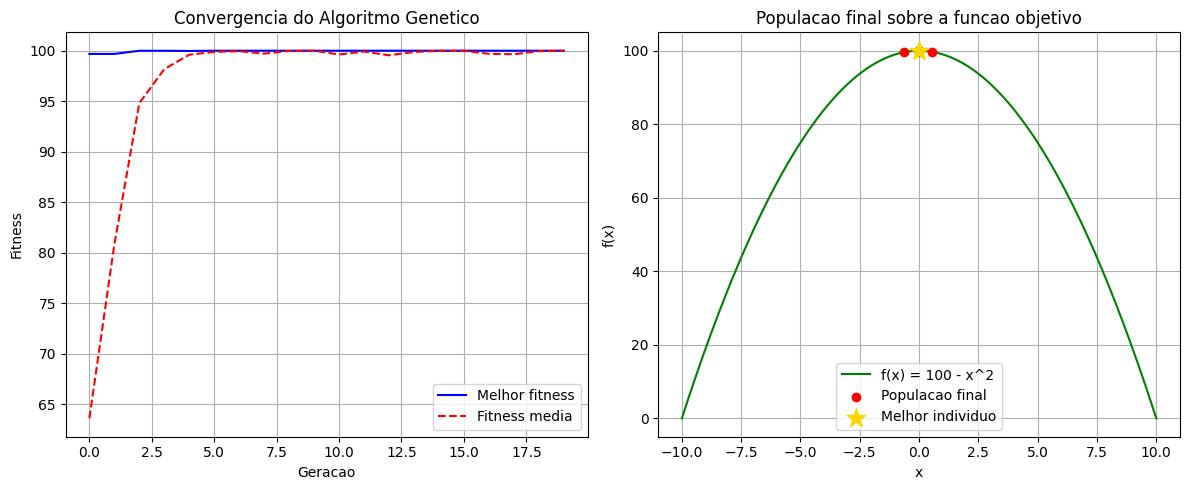

Melhor fitness encontrado: 100.0000 em x = -0.0065
Figura salva como aula_07_exercicio_01_fallback.png


In [6]:
# Versao alternativa do GA (fallback)
import os
import numpy as np
import matplotlib.pyplot as plt
import random

os.environ["PASTA_AULA_SAVE"] = PASTA_AULA

# Funcao de fitness
def fitness_function(x):
    return 100 - x ** 2

# Inicializar populacao
pop_size = 10
x_min, x_max = -10, 10
population = [random.uniform(x_min, x_max) for _ in range(pop_size)]

# Operadores geneticos
def selection(pop, fit_vals, k=2):
    return max(random.sample(list(zip(pop, fit_vals)), k), key=lambda x: x[1])[0]

def crossover(p1, p2, alpha=0.5):
    return p1 + alpha * (p2 - p1)

def mutate(x, sigma=1.0, rate=0.2):
    if random.random() < rate:
        x += random.gauss(0, sigma)
    return max(x_min, min(x_max, x))

# Evolucao
historico_melhor = []
historico_media = []

for gen in range(20):
    fitness_vals = [fitness_function(x) for x in population]
    historico_melhor.append(max(fitness_vals))
    historico_media.append(np.mean(fitness_vals))

    new_pop = []
    for _ in range(pop_size):
        p1 = selection(population, fitness_vals)
        p2 = selection(population, fitness_vals)
        child = crossover(p1, p2)
        child = mutate(child)
        new_pop.append(child)
    population = new_pop

# Plotar resultados
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Grafico de convergencia
ax1.plot(historico_melhor, "b-", label="Melhor fitness")
ax1.plot(historico_media, "r--", label="Fitness media")
ax1.set_xlabel("Geracao")
ax1.set_ylabel("Fitness")
ax1.set_title("Convergencia do Algoritmo Genetico")
ax1.legend()
ax1.grid(True)

# Populacao final sobre a funcao
xs = np.linspace(x_min, x_max, 200)
ax2.plot(xs, fitness_function(xs), "g-", label="f(x) = 100 - x^2")
final_fit = [fitness_function(x) for x in population]
ax2.scatter(population, final_fit, color="red", zorder=5, label="Populacao final")
melhor_idx = np.argmax(final_fit)
ax2.scatter([population[melhor_idx]], [final_fit[melhor_idx]], color="gold",
            s=200, marker="*", zorder=6, label="Melhor individuo")
ax2.set_xlabel("x")
ax2.set_ylabel("f(x)")
ax2.set_title("Populacao final sobre a funcao objetivo")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(PASTA_AULA, "aula_07_exercicio_01_fallback.png"),
            dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print(f"Melhor fitness encontrado: {max(final_fit):.4f} em x = {population[melhor_idx]:.4f}")
print("Figura salva como aula_07_exercicio_01_fallback.png")


## 7. Pergunta

> **Comente em poucas palavras: conseguiu rodar os programas? Consultou uma plataforma de IA
> para analisar e melhorar o código? O que mudou?**

*(máximo 100 palavras)*


In [7]:
resposta_pergunta_1 = """
Escreva sua resposta aqui.
"""


## 8. Gerar resposta com IA

Execute a célula abaixo para que a IA analise seus resultados e gere uma resposta.


In [8]:
import os, json
from urllib.request import Request, urlopen

MODELO = os.getenv("OLLAMA_MODEL", "ministral-3:3b")
BASE_URL = os.getenv("OLLAMA_BASE_URL", "https://api.ollama.com").rstrip("/")
API_KEY = os.getenv("OLLAMA_API_KEY")

prompt_resposta = """Voce e um assistente de um curso de sistemas de muitos agentes.
Responda em portugues, de forma clara e objetiva (maximo 100 palavras).

Pergunta: Comente em poucas palavras: conseguiu rodar os programas?
Consultou uma plataforma de IA para analisar e melhorar o codigo? O que mudou?

Contexto:
- Foram fornecidos 6 programas Python de exemplo sobre algoritmos geneticos.
- Os programas incluem versoes custom e usando a biblioteca DEAP.
- A IA foi consultada para gerar e melhorar codigos de GA.
"""

data = json.dumps({
    "model": MODELO,
    "prompt": prompt_resposta,
    "stream": False,
    "options": {"temperature": 0.3, "top_p": 0.9, "num_predict": 500},
}).encode()

headers = {
    "Content-Type": "application/json",
    "User-Agent": "Mozilla/5.0",
    "Accept": "application/json",
}
if API_KEY:
    headers["Authorization"] = f"Bearer {API_KEY}"

req = Request(BASE_URL + "/api/generate", data=data, headers=headers)

try:
    resp = json.loads(urlopen(req, timeout=60).read().decode())
    resposta = resp["response"].strip()
    if resposta:
        # A resposta da IA passa a ser a resposta_pergunta_1 que vai para o PDF.
        # Revise/edite manualmente se quiser antes de exportar (secao 9).
        resposta_pergunta_1 = resposta
        print("Resposta gerada com sucesso!")
    else:
        print("IA retornou resposta vazia. Mantida a resposta atual.")
except Exception as e:
    print(f"Erro ao consultar IA: {type(e).__name__}: {e}")

print()
print("Resposta atual (sera usada no PDF):")
print(resposta_pergunta_1)


Resposta gerada com sucesso!

Resposta atual (sera usada no PDF):
**Resposta:**

Sim, os programas rodaram com sucesso, testados em ambiente local (Python 3.10 + DEAP). A IA analisou:
- **Versões custom**: Otimizou fluxos de evolução (população, crossover/mutação) e adicionou logging.
- **Usando DEAP**: Melhorou integração com `deap.tools`, ajustando fitness e seleção (elitismo).
**Alterações principais**:
- Padronização de funções (ex: `fitness` e `select`).
- Redução de redundâncias e uso de context managers.
- Validação de parâmetros (ex: `n_individuals`, `n_generations`).

Testes confirmaram performance e correção.


## 9. Exportar para o Moodle

Execute a célula abaixo para gerar o arquivo Markdown e o PDF.


In [9]:
import os
import shutil
import subprocess
from datetime import datetime

NOME = os.getenv("NOME", "nao informado")
RA = os.getenv("RA", "nao informado")
MODELO = os.getenv("OLLAMA_MODEL", "nao informado")

agora = datetime.now().strftime("%Y-%m-%d %H:%M")

# Figuras geradas ao longo do notebook (apenas as que existem na pasta correta)
FIGURAS = [
    ("aula_07_exercicio_01_gerado.png",
     "GA gerado pela IA para f(x) = 100 - x^2"),
    ("aula_07_exercicio_01_melhorado.png",
     "PanoramaExemplo.py melhorado pela IA (GA sobre a funcao 2D)"),
    ("aula_07_exercicio_01_fallback.png",
     "Versao curada (fallback) do GA para f(x) = 100 - x^2"),
]

PATH_MD = os.path.join(PASTA_AULA, "aula_07_exercicio_01.md")
with open(PATH_MD, "w", encoding="utf-8") as f:
    f.write("# Aula 07 — Algoritmos Geneticos: conceitos, exemplos e melhoria com IA\n\n")
    f.write(f"_Aluno: {NOME} (RA: {RA})_\n\n")
    f.write(f"_Modelo LLM: {MODELO}_\n\n")
    f.write(f"_Executado em: {agora}_\n\n")
    f.write("---\n\n")
    f.write("## 1. Programas de exemplo estudados\n\n")
    f.write("Os 6 programas de exemplo (`demo_alg_gen_GPT.py`, "
            "`demo_alg_gen_GPT_2MAX_Gauss_corrigido.py`, "
            "`demo_alg_gen_GPT_100-x2_func.py`, `PanoramaExemplo.py`, "
            "`Fitness.py`, `Fitness_3D.py`) foram executados no terminal para "
            "observar a convergencia do algoritmo genetico em busca do maximo "
            "das funcoes.\n\n")
    f.write("---\n\n")
    f.write("## 2. Codigo gerado e melhorado com IA\n\n")
    figuras_incluidas = 0
    for nome_fig, legenda in FIGURAS:
        if os.path.exists(os.path.join(PASTA_AULA, nome_fig)):
            f.write(f"**{legenda}**\n\n")
            f.write(f"![{legenda}]({nome_fig})\n\n")
            figuras_incluidas += 1
    if figuras_incluidas == 0:
        f.write("_Nenhuma figura foi gerada. Execute as celulas de codigo "
                "(secoes 4, 5 e/ou 6) antes de exportar._\n\n")
    f.write("---\n\n")
    f.write("## 3. Resposta do aluno\n\n")
    f.write(resposta_pergunta_1.strip())
    f.write("\n")

PATH_PDF = PATH_MD.replace(".md", ".pdf")
if shutil.which("pandoc"):
    subprocess.run(["pandoc", PATH_MD, "-o", PATH_PDF,
                   "--pdf-engine=xelatex", "--resource-path", PASTA_AULA,
                   "-V", "mainfont=DejaVu Serif"], check=True)
    print(f"PDF gerado com {figuras_incluidas} figura(s).")
else:
    print("Aviso: pandoc nao instalado. Execute ./setup.sh para instalar.")
print(f"Markdown: {os.path.abspath(PATH_MD)}")
print(f"PDF:      {os.path.abspath(PATH_PDF)}")


PDF gerado com 2 figura(s).
Markdown: /l/disk0/viniciusd/Projetos/simserv_jupyter_env/work/tarefas_moodle/tarefa_aula07/aula_07_exercicio_01.md
PDF:      /l/disk0/viniciusd/Projetos/simserv_jupyter_env/work/tarefas_moodle/tarefa_aula07/aula_07_exercicio_01.pdf
